# Catalog checks (2026-05-12)

Section 1: load a **uniform** mock catalog (`mocks_uniform`, comoving-volume $z$) and plot tracer properties in the same style as `2025-09-04_mocks_viz.ipynb` and the tracer section of `2025-05-30_mocks_glass.ipynb`.

Section 2: load inference / MCMC results using `plotter`, following `2026-05-05_mcmc_checks.ipynb`.

## 1. Uniform catalog

Directory tags omit `_bgal*` / `_bagn*` for uniform mocks (see `generate_configs.py`). Adjust `seed` and `ratio` to match the mock you generated.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%load_ext autoreload
%autoreload 2

sys.path.append("../code")
import make_mocks as mm
import plotter

In [3]:
ratio = 1
seed = 0
tag_mock = f"_seed{seed}_ratioNgalNagn{ratio:d}"
dir_mock = os.path.join("..", "data", "mocks_uniform", f"mock{tag_mock}")
fn_mock = os.path.join(dir_mock, "mock_catalog.h5")
print(fn_mock)
if not os.path.isfile(fn_mock):
    raise FileNotFoundError(
        f"Catalog not found: {fn_mock}\n"
        "Generate a uniform mock (e.g. make_mocks with tag_mocktype _uniform) or edit seed/ratio."
    )

../data/mocks_uniform/mock_seed0_ratioNgalNagn1/mock_catalog.h5


In [4]:
ra_gal, dec_gal, z_gal, ra_agn, dec_agn, z_agn, attrs = mm.load_mock_catalog(fn_mock)
print("n_gal", len(ra_gal), "n_agn", len(ra_agn))
print("HDF5 attrs (sample):", {k: attrs[k] for k in list(attrs)[:12]})

load_mock_catalog: opening ../data/mocks_uniform/mock_seed0_ratioNgalNagn1/mock_catalog.h5 for read
load_mock_catalog: reading ra_gal ...
load_mock_catalog: reading dec_gal ...
load_mock_catalog: reading z_gal ...
load_mock_catalog: reading ra_agn ...
load_mock_catalog: reading dec_agn ...
load_mock_catalog: reading z_agn ...
load_mock_catalog: copying attrs ...
load_mock_catalog: done (n_gal=1485587, n_agn=1481976, ~0.071 GB raw float64 for six position arrays)
n_gal 1485587 n_agn 1481976
HDF5 attrs (sample): {'Ob': np.float64(0.0486), 'Oc': np.float64(0.2589), 'h': np.float64(0.6774), 'n_agn': np.int64(1481976), 'n_gal': np.int64(1485587), 'nside': np.int64(64), 'seed': np.int64(0), 'z_max': np.float64(1.5)}


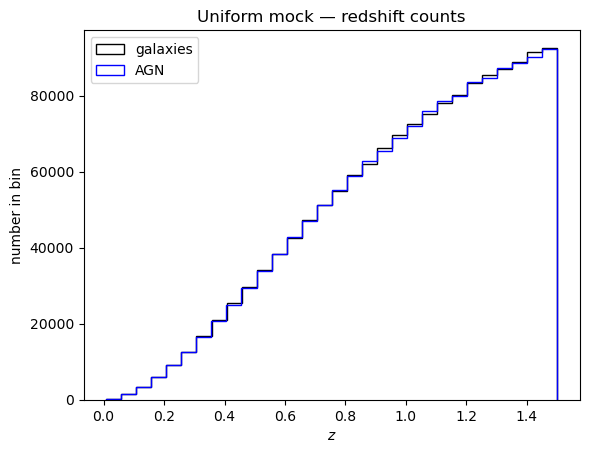

In [5]:
bins = 30
plt.hist(z_gal, label="galaxies", color="black", density=False, bins=bins, histtype="step")
plt.hist(z_agn, label="AGN", color="blue", density=False, bins=bins, histtype="step")
plt.xlabel(r"$z$")
plt.ylabel("number in bin")
plt.legend()
plt.title("Uniform mock — redshift counts")
plt.show()

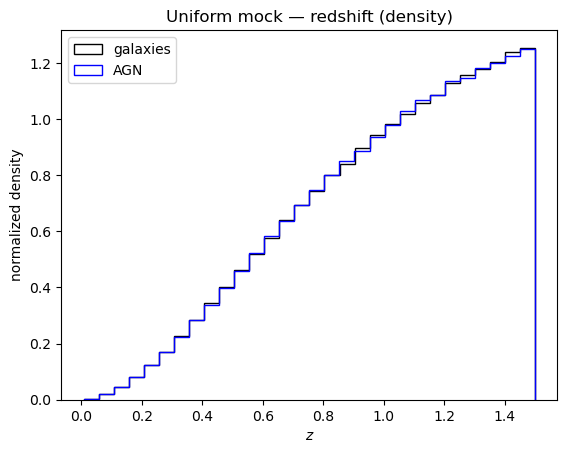

In [6]:
bins = 30
plt.hist(z_gal, label="galaxies", color="black", density=True, bins=bins, histtype="step")
plt.hist(z_agn, label="AGN", color="blue", density=True, bins=bins, histtype="step")
plt.xlabel(r"$z$")
plt.ylabel("normalized density")
plt.legend()
plt.title("Uniform mock — redshift (density)")
plt.show()

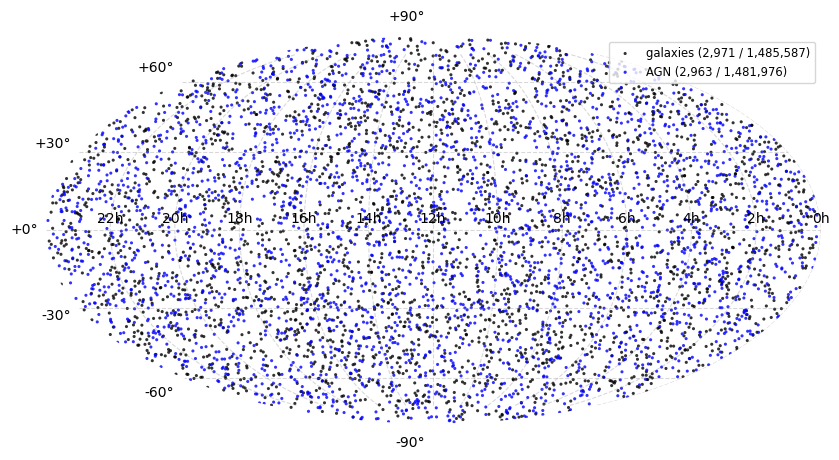

In [10]:
frac = 0.002  # 0.2% subsample for plotting
rng_sky = np.random.default_rng(seed)
n_gal_s = max(1, int(frac * len(ra_gal)))
n_agn_s = max(1, int(frac * len(ra_agn)))
i_gal = rng_sky.choice(len(ra_gal), size=n_gal_s, replace=False)
i_agn = rng_sky.choice(len(ra_agn), size=n_agn_s, replace=False)

ra_arr = [ra_gal[i_gal], ra_agn[i_agn]]
dec_arr = [dec_gal[i_gal], dec_agn[i_agn]]
c_arr = ["k", "b"]
alpha_arr = [0.8,0.8]
s_arr = [5, 5]
label_arr = [f"galaxies ({n_gal_s:,} / {len(ra_gal):,})", f"AGN ({n_agn_s:,} / {len(ra_agn):,})"]

plotter.create_skyplot(ra_arr, dec_arr, alpha_arr=alpha_arr, s_arr=s_arr, c_arr=c_arr, label_arr=label_arr)
plt.show()

### GW injection hosts

Same idea as `mocks_viz`: load `gws*.h5` from the same `dir_mock` and plot the sky positions of GW host galaxies and AGN. Pipeline configs name this file `gws{tag_gw}.h5` with `tag_gw = _seedgw{seed+1000}_fagn…_lambdaagn…_zmaxgw…` (see `generate_configs.py`). Adjust `f_agn`, `lambda_agn`, and `z_max_gw` if your mock used different values.

../data/mocks_uniform/mock_seed0_ratioNgalNagn1/gws_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0.h5


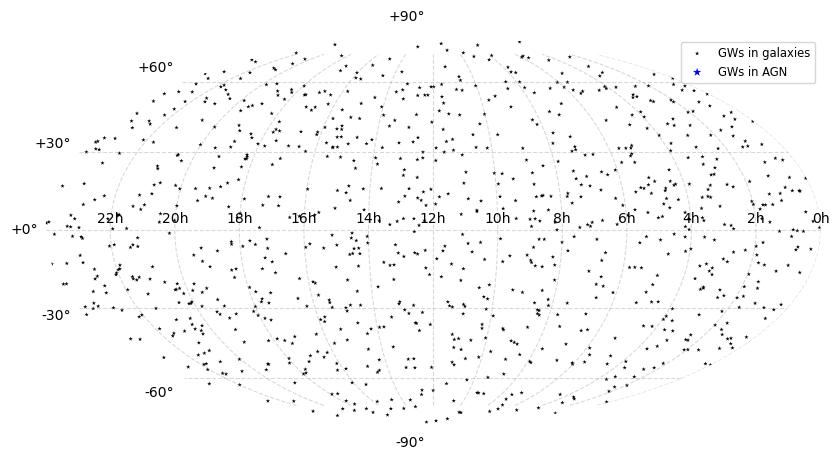

In [8]:
# Must match the GW injection file written under dir_mock
gw_seed = seed + 1000
f_agn = 0.0
lambda_agn = 0.0
z_max_gw = 1.0

tag_gw = f"_seedgw{gw_seed}_fagn{f_agn}_lambdaagn{lambda_agn}_zmaxgw{z_max_gw}"
fn_gw = os.path.join(dir_mock, f"gws{tag_gw}.h5")
print(fn_gw)

if not os.path.isfile(fn_gw):
    raise FileNotFoundError(
        f"GW injection file not found: {fn_gw}\n"
        "Edit f_agn, lambda_agn, z_max_gw (and gw_seed if needed) or run the mock pipeline."
    )

i_gw_gal, i_gw_agn, gw_attrs = mm.load_gw_injection(fn_gw)
ra_gw_arr = [ra_gal[i_gw_gal], ra_agn[i_gw_agn]]
dec_gw_arr = [dec_gal[i_gw_gal], dec_agn[i_gw_agn]]

c_arr = ["k", "b"]
alpha_arr = [1, 1]
s_arr = [10, 40]
label_arr = ["GWs in galaxies", "GWs in AGN"]
marker_arr = ["*", "*"]

plotter.create_skyplot(
    ra_gw_arr,
    dec_gw_arr,
    alpha_arr=alpha_arr,
    s_arr=s_arr,
    c_arr=c_arr,
    label_arr=label_arr,
    marker_arr=marker_arr,
)
plt.show()

## 2. Inference results (MCMC)

Point `fn_config_inference` at a YAML under `configs/configs_inference/` (as in `mcmc_checks`). The HDF5 path is resolved inside `plotter.get_mcmc_data`.

**Uniform mocks:** generated inference configs use the prefix `config_inference_uniform` and a `tag_cat` without `_bgal` / `_bagn` (see `generate_configs.create_config_inference`). The example `tag_data` below matches the existing **GLASS** naming from `mcmc_checks`; swap it for your `_uniform` basename if you ran inference on a uniform catalog.

In [11]:
dir_configs = "../configs/configs_inference"
tag_data = "_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunc0.0"
tag_inf = "_mcmc_nw32_nsteps500_Dz0.03_betaH0_vary-H0"
fn_config_inference = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
print(fn_config_inference)

../configs/configs_inference/config_inference_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunc0.0_mcmc_nw32_nsteps500_Dz0.03_betaH0_vary-H0.yaml


Loading inference results from ../results/inference/inference_results_uniform_seed0_ratioNgalNagn1_nside64_seedgw1000_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunc0.0_mcmc_nw32_nsteps500_Dz0.03_betaH0_vary-H0.h5
Only 1 parameter varied; using 1D marginalized plot instead of corner.


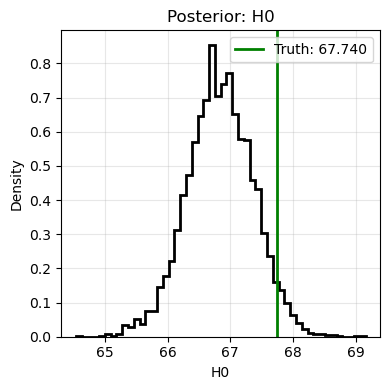

In [12]:
mcmc_data = plotter.get_mcmc_data(fn_config_inference)
plotter.plot_mcmc_contours(mcmc_data)

### Optional: several mock seeds (same pattern as `mcmc_checks`)

In [ ]:
seeds = [0, 1, 2, 3, 4]
mcmc_data_arr = []
for seed in seeds:
    seedgw = 1000 + seed
    tag_data = (
        f"_seed{seed}_ratioNgalNagn1_bgal1.0_bagn1.0_nside64_seedgw{seedgw}"
        f"_fagn0.0_lambdaagn0.0_zmaxgw1.0_dLunc0.0"
    )
    tag_inf = "_mcmc_nw32_nsteps500_Dz0.03_betaH0_vary-H0"
    fn_cfg = f"{dir_configs}/config_inference{tag_data}{tag_inf}.yaml"
    mcmc_data_arr.append(plotter.get_mcmc_data(fn_cfg))

plotter.plot_mcmc_contours(
    mcmc_data_arr,
    title=r"Several mock seeds ($\sigma_{dL}=0.0$)",
)